# Task 1: Data Preparation


In [7]:
#first we need to import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 6)

In [8]:
#importing the dataset into the project
df_raw = pd.read_csv("victorian_road_crash_data.csv")
df = df_raw.copy()

df.shape

(150452, 52)

In [9]:
print("Duplicate rows:", df.duplicated().sum()) #checking for the duplicates

Duplicate rows: 2


In [10]:
df = df.drop_duplicates()

In [11]:
#next we need to check the missig values
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

SRNS                105454
DIVIDED               6732
RMA                   6732
ROAD_TYPE             2105
STAT_DIV_NAME          969
DEG_URBAN_NAME         948
ROAD_NAME              218
LGA_NAME                53
VICGRID_Y               48
VICGRID_X               48
LONGITUDE               48
LATITUDE                48
DTP_REGION              48
ROAD_ROUTE_1            48
NO_OF_VEHICLES           9
HEAVYVEHICLE             9
PASSENGERVEHICLE         9
MOTORCYCLE               9
PT_VEHICLE               9
dtype: int64

In [12]:
#some colums contains spcaes so that we need to remove that first
text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

In [13]:
#next of we convert the time to HHMM
df["ACCIDENT_TIME"] = pd.to_datetime(
    df["ACCIDENT_TIME"].astype(str).str.zfill(4),
    format="%H%M",
    errors="coerce"
)

In [14]:
# Convert accident date into datetime format
df["ACCIDENT_DATE"] = pd.to_datetime(df["ACCIDENT_DATE"], errors="coerce")

In [15]:
df["ACCIDENT_DATE"].dtype

dtype('<M8[ns]')

In [16]:
df["YEAR"] = df["ACCIDENT_DATE"].dt.year
df["HOUR"] = df["ACCIDENT_TIME"].dt.hour

In [17]:
#getting the time of the day
def get_time_of_day(hour):
    if pd.isna(hour):
        return "Unknown"
    elif 0 <= hour < 6:
        return "Late Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df["TIME_OF_DAY"] = df["HOUR"].apply(get_time_of_day)

In [18]:
#cleaning the speed zone
df["SPEED_ZONE_CLEAN"] = df["SPEED_ZONE"].astype(str).str.extract(r"(\d+)")[0]
df["SPEED_ZONE_CLEAN"] = pd.to_numeric(df["SPEED_ZONE_CLEAN"], errors="coerce")

valid_speeds = [30, 40, 50, 60, 70, 75, 80, 90, 100, 110]
df.loc[~df["SPEED_ZONE_CLEAN"].isin(valid_speeds), "SPEED_ZONE_CLEAN"] = None

In [19]:
for col in ["LGA_NAME", "DTP_REGION", "ROAD_GEOMETRY", "LIGHT_CONDITION"]:
    df[col] = df[col].fillna("Unknown")

In [20]:
num_cols = ["INJ_OR_FATAL", "FATALITY", "SERIOUSINJURY", "OTHERINJURY"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [21]:
df.to_csv("cleaned_version.csv", index=False)
print("Cleaned dataset saved ")

Cleaned dataset saved 


# Task 2: Data Exploration

## Q1 accident frequencies vary by the Day of the Week and Time of Day

In [22]:
df_2023 = df[df["YEAR"] == 2023]

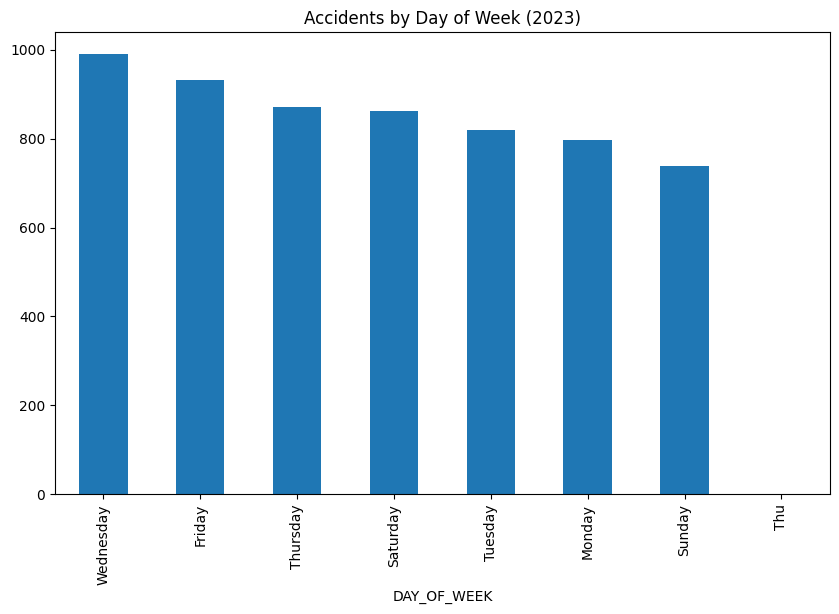

In [23]:
df_2023["DAY_OF_WEEK"].value_counts().plot(kind="bar")
plt.title("Accidents by Day of Week (2023)")
plt.show()

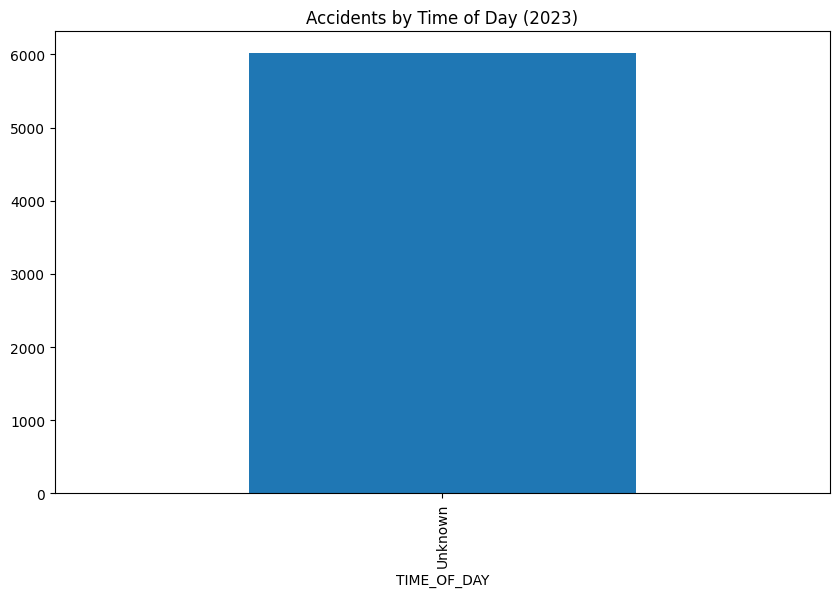

In [24]:
df_2023["TIME_OF_DAY"].value_counts().plot(kind="bar")
plt.title("Accidents by Time of Day (2023)")
plt.show()

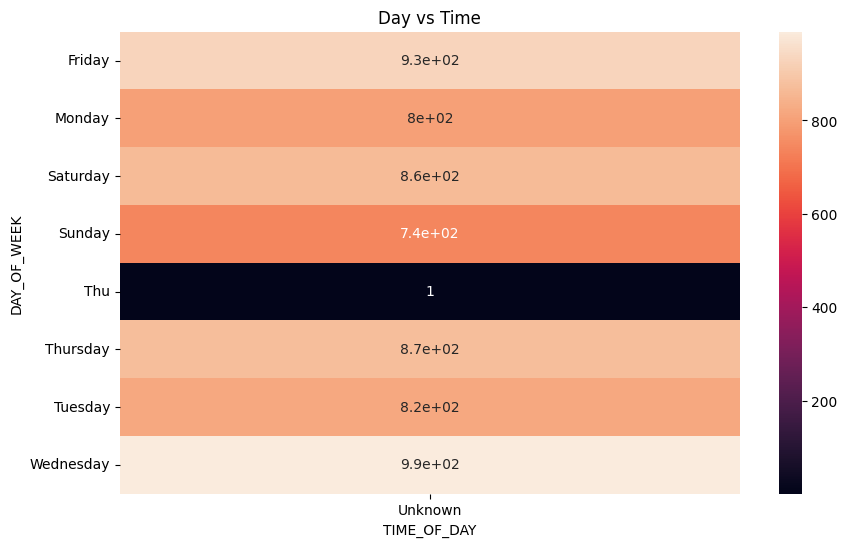

In [25]:
import seaborn as sns

heat = pd.crosstab(df_2023["DAY_OF_WEEK"], df_2023["TIME_OF_DAY"])
sns.heatmap(heat, annot=True)
plt.title("Day vs Time")
plt.show()

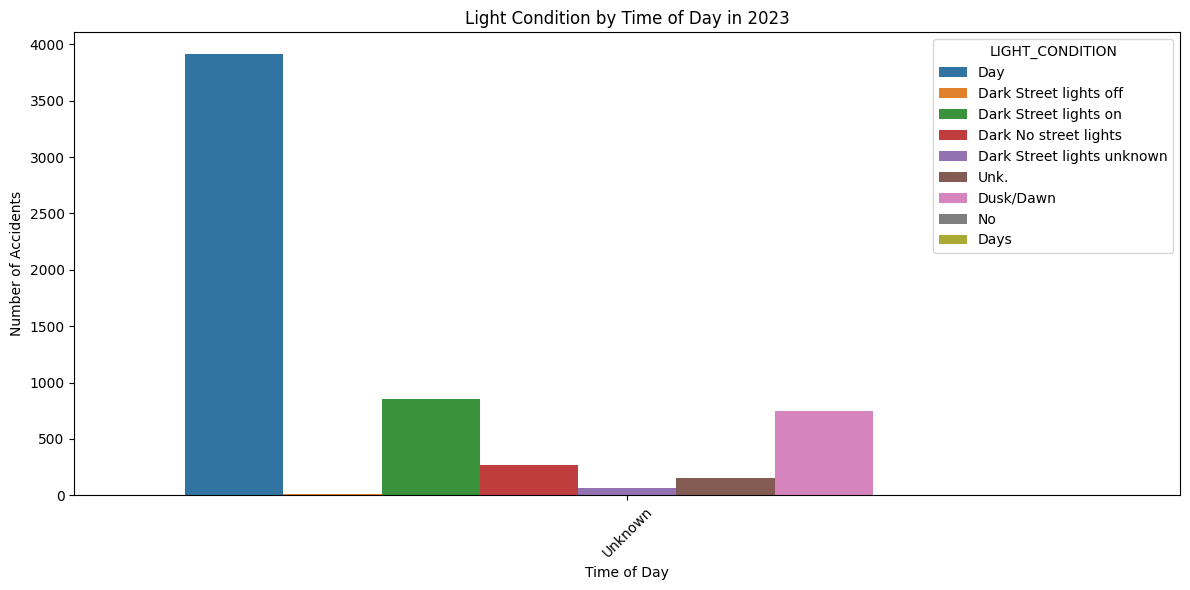

In [26]:
# Compare light condition across time of day in 2023
plt.figure(figsize=(12, 6))
sns.countplot(data=df_2023, x="TIME_OF_DAY", hue="LIGHT_CONDITION")
plt.title("Light Condition by Time of Day in 2023")
plt.xlabel("Time of Day")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Q2 Relation between SPEED_ZONE and INJ_OR_FATAL

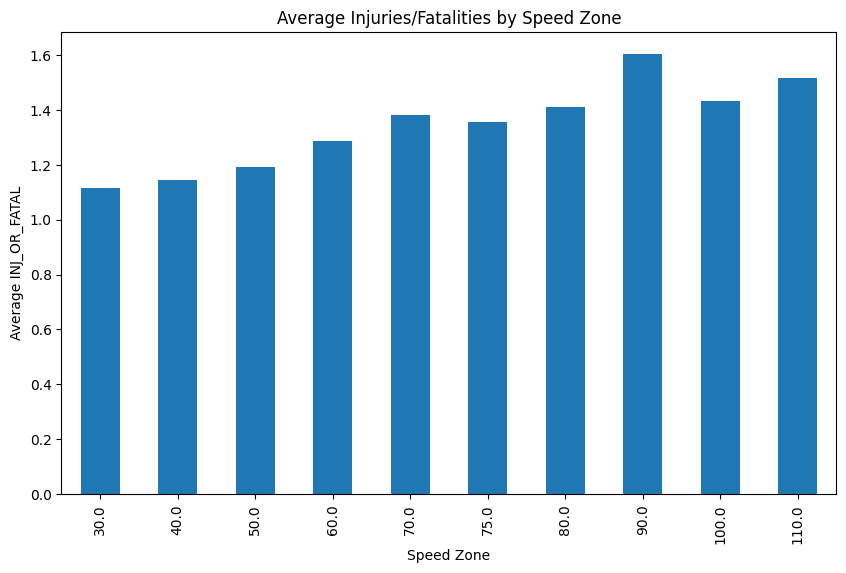

In [27]:
#Average injuries by speed
df.groupby("SPEED_ZONE_CLEAN")["INJ_OR_FATAL"].mean().plot(kind="bar")
plt.title("Average Injuries/Fatalities by Speed Zone")
plt.xlabel("Speed Zone")
plt.ylabel("Average INJ_OR_FATAL")
plt.show()

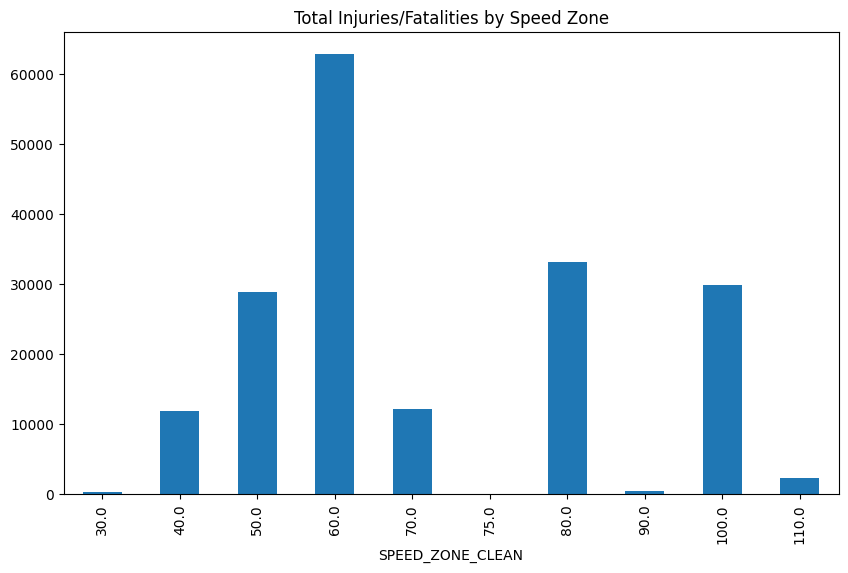

In [28]:
#Total injuries
df.groupby("SPEED_ZONE_CLEAN")["INJ_OR_FATAL"].sum().plot(kind="bar")
plt.title("Total Injuries/Fatalities by Speed Zone")
plt.show()

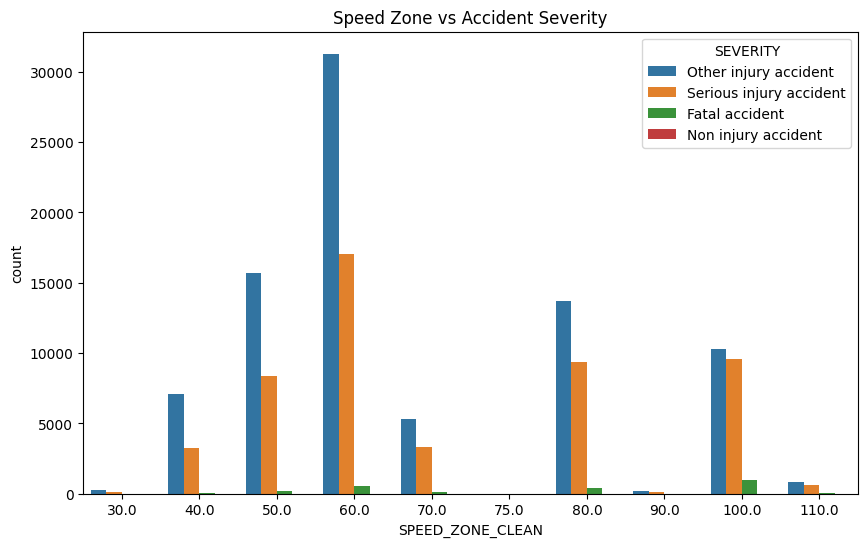

In [29]:
#Compare severity
import seaborn as sns

sns.countplot(data=df, x="SPEED_ZONE_CLEAN", hue="SEVERITY")
plt.title("Speed Zone vs Accident Severity")
plt.show()

## Q3 analyzing crash distribution

In [30]:
top5_lga = df["LGA_NAME"].value_counts().head(5)
print(top5_lga)  #this is for top5 ares 

LGA_NAME
MELBOURNE    7595
CASEY        7127
GEELONG      6059
HUME         5651
DANDENONG    5183
Name: count, dtype: int64


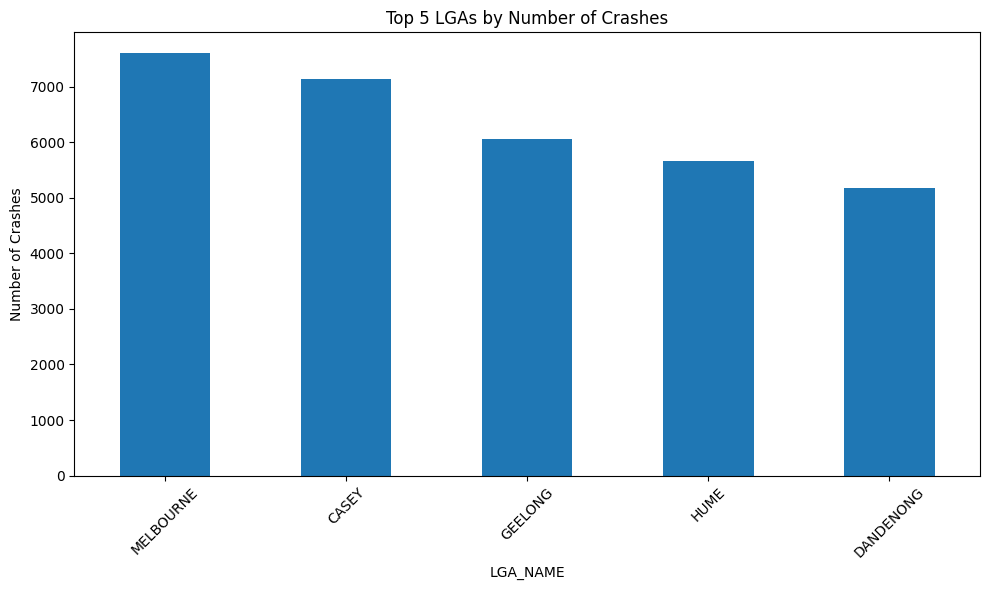

In [31]:
top5_lga.plot(kind="bar")
plt.title("Top 5 LGAs by Number of Crashes")
plt.xlabel("LGA_NAME")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() #representing in bar chart

In [32]:
#let us filter the dataset
top5_names = top5_lga.index
df_top5 = df[df["LGA_NAME"].isin(top5_names)].copy()

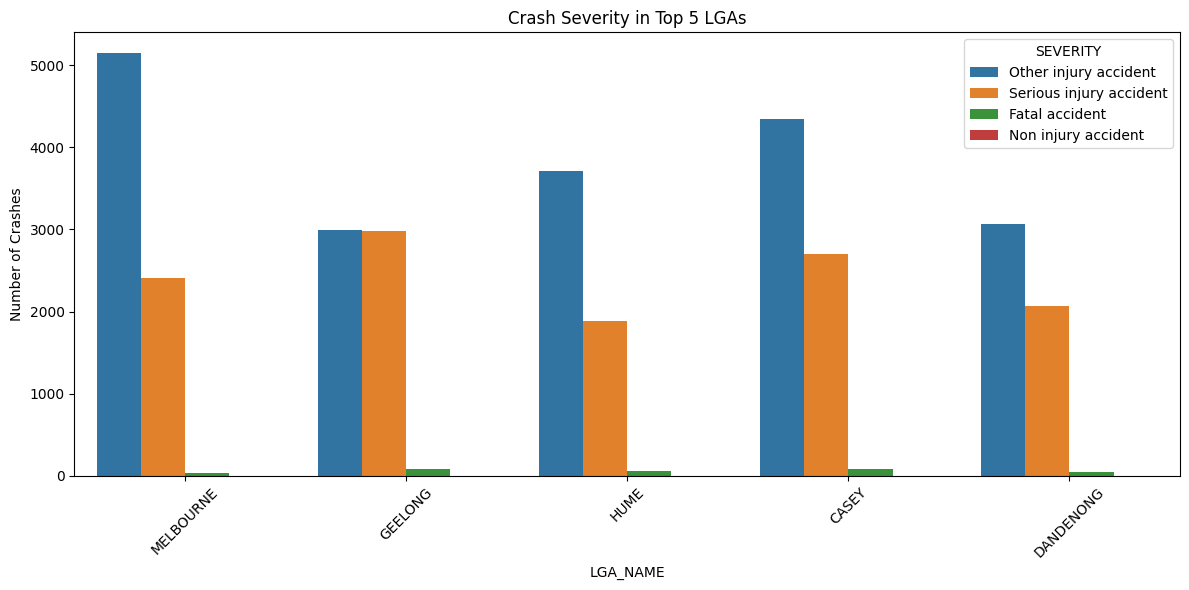

In [33]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(data=df_top5, x="LGA_NAME", hue="SEVERITY")
plt.title("Crash Severity in Top 5 LGAs")
plt.xlabel("LGA_NAME")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

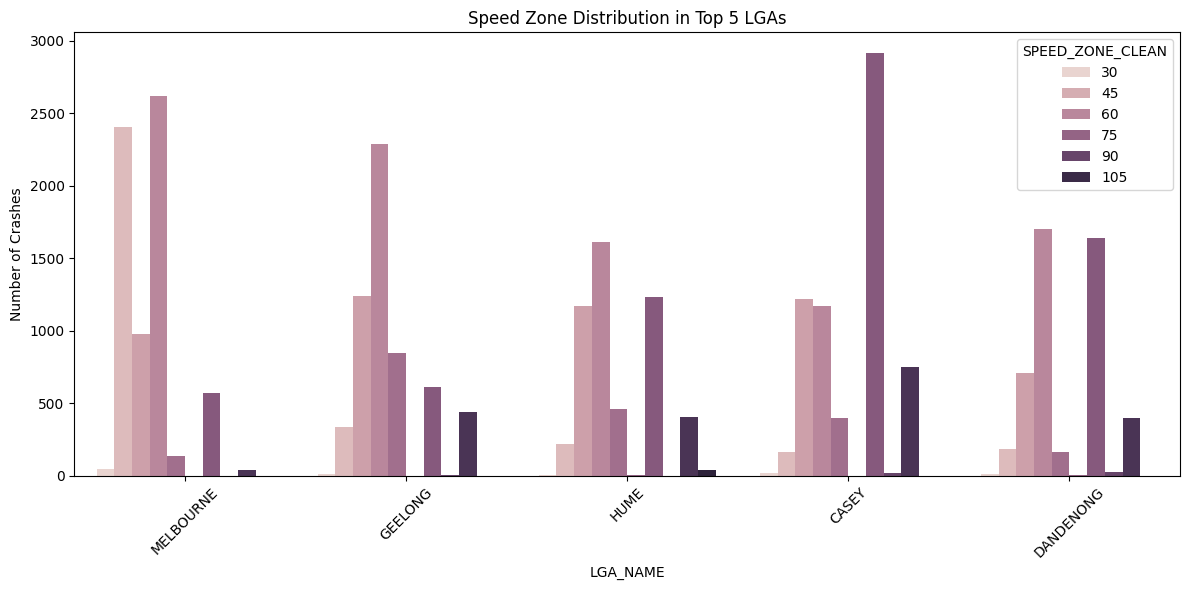

In [34]:
#comparing speed zone
plt.figure(figsize=(12,6))
sns.countplot(data=df_top5, x="LGA_NAME", hue="SPEED_ZONE_CLEAN")
plt.title("Speed Zone Distribution in Top 5 LGAs")
plt.xlabel("LGA_NAME")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

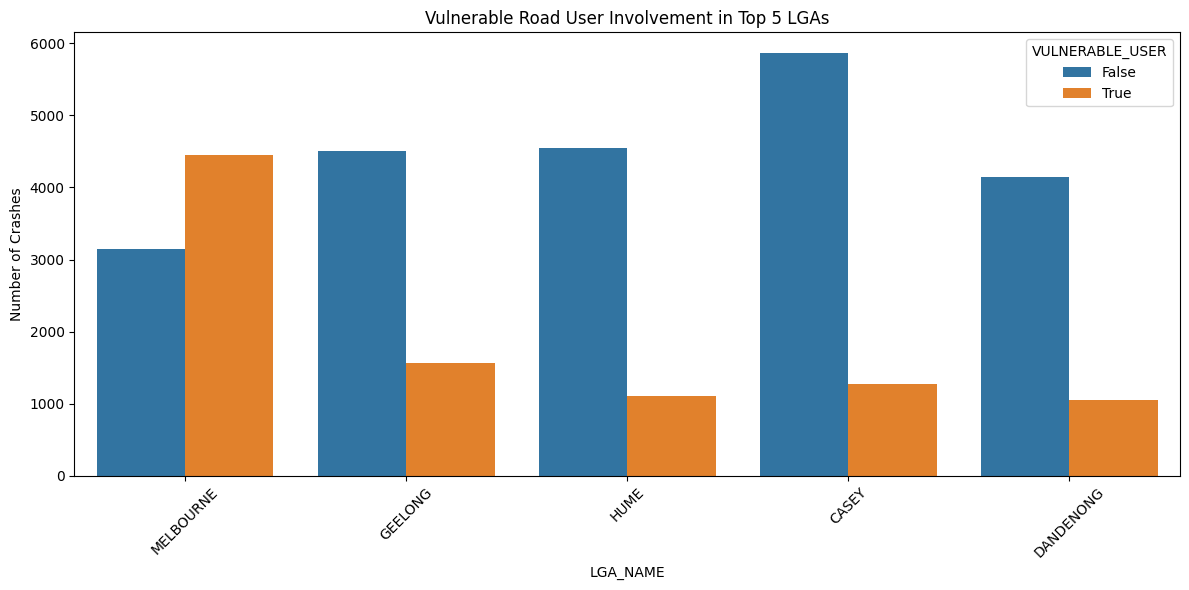

In [35]:
#comparing vulnerable users
df_top5["VULNERABLE_USER"] = (
    (df_top5["PEDESTRIAN"] > 0) |
    (df_top5["BICYCLIST"] > 0) |
    (df_top5["MOTORCYCLIST"] > 0)
)

plt.figure(figsize=(12,6))
sns.countplot(data=df_top5, x="LGA_NAME", hue="VULNERABLE_USER")
plt.title("Vulnerable Road User Involvement in Top 5 LGAs")
plt.xlabel("LGA_NAME")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()